In [2]:
import pandas as pd
import numpy as np
import wfdb
import matplotlib.pyplot as plt
import os

# This path should now be correct and persistent
DATA_PATH = '/workspace/project/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/'

# --- Load the main metadata file ---
df_meta = pd.read_csv(os.path.join(DATA_PATH, 'ptbxl_database.csv'), index_col='ecg_id')

# --- Display the first 5 rows and a summary ---
print("--- Metadata (Top 5 Rows): ---")
display(df_meta.head())

print("\n--- Summary Info: ---")
df_meta.info()

--- Metadata (Top 5 Rows): ---


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr



--- Summary Info: ---
<class 'pandas.core.frame.DataFrame'>
Index: 21799 entries, 1 to 21837
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_id                    21799 non-null  float64
 1   age                           21799 non-null  float64
 2   sex                           21799 non-null  int64  
 3   height                        6974 non-null   float64
 4   weight                        9421 non-null   float64
 5   nurse                         20326 non-null  float64
 6   site                          21782 non-null  float64
 7   device                        21799 non-null  object 
 8   recording_date                21799 non-null  object 
 9   report                        21799 non-null  object 
 10  scp_codes                     21799 non-null  object 
 11  heart_axis                    13331 non-null  object 
 12  infarction_stadium1           5612 non-nul

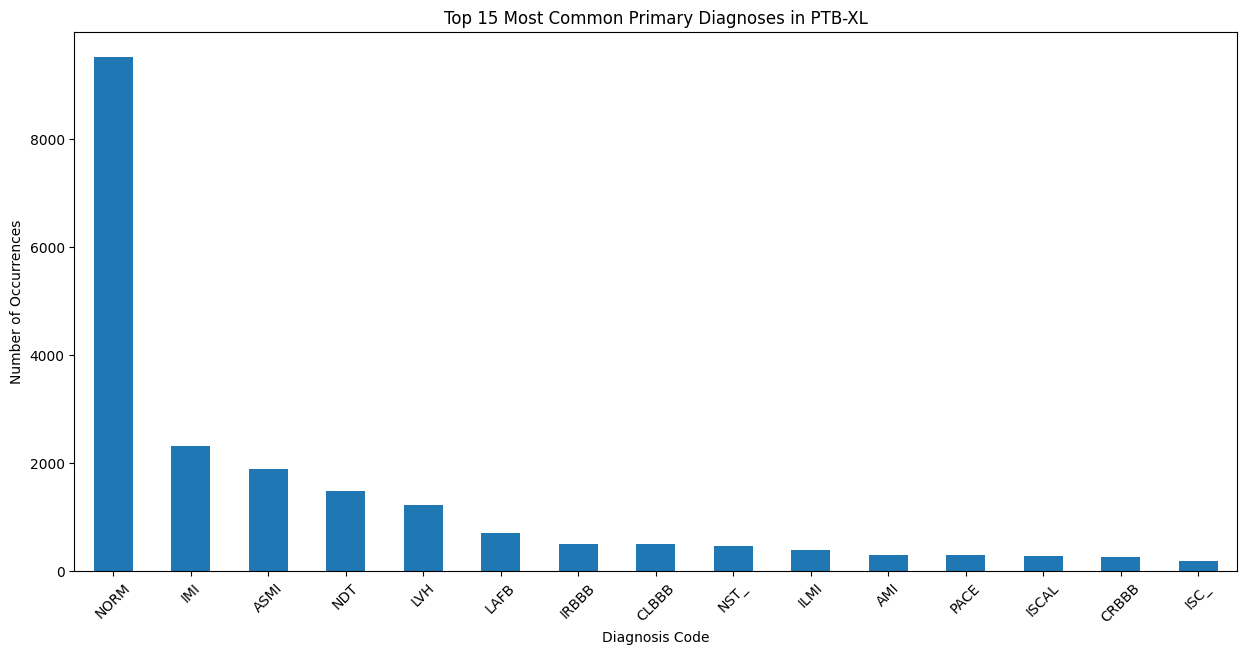

In [3]:
# --- Task B: Analyze the Class Distribution ---
# The 'scp_codes' column contains the diagnoses as a dictionary string.
# We need to parse it to make it usable.
import ast
import matplotlib.pyplot as plt

df_meta['scp_codes'] = df_meta.scp_codes.apply(lambda x: ast.literal_eval(x))

# Let's count the occurrences of each diagnosis
# We will use a function to extract the first (primary) diagnosis for simplicity
def get_primary_diagnosis(scp_dict):
    # The keys of the dictionary are the diagnosis codes
    # We'll take the first key as the primary diagnosis
    try:
        return list(scp_dict.keys())[0]
    except IndexError:
        return None

df_meta['primary_diagnosis'] = df_meta.scp_codes.apply(get_primary_diagnosis)

# Now, let's count and plot the most common diagnoses
plt.figure(figsize=(15, 7))
df_meta['primary_diagnosis'].value_counts().nlargest(15).plot(kind='bar')
plt.title('Top 15 Most Common Primary Diagnoses in PTB-XL')
plt.ylabel('Number of Occurrences')
plt.xlabel('Diagnosis Code')
plt.xticks(rotation=45)
plt.show()


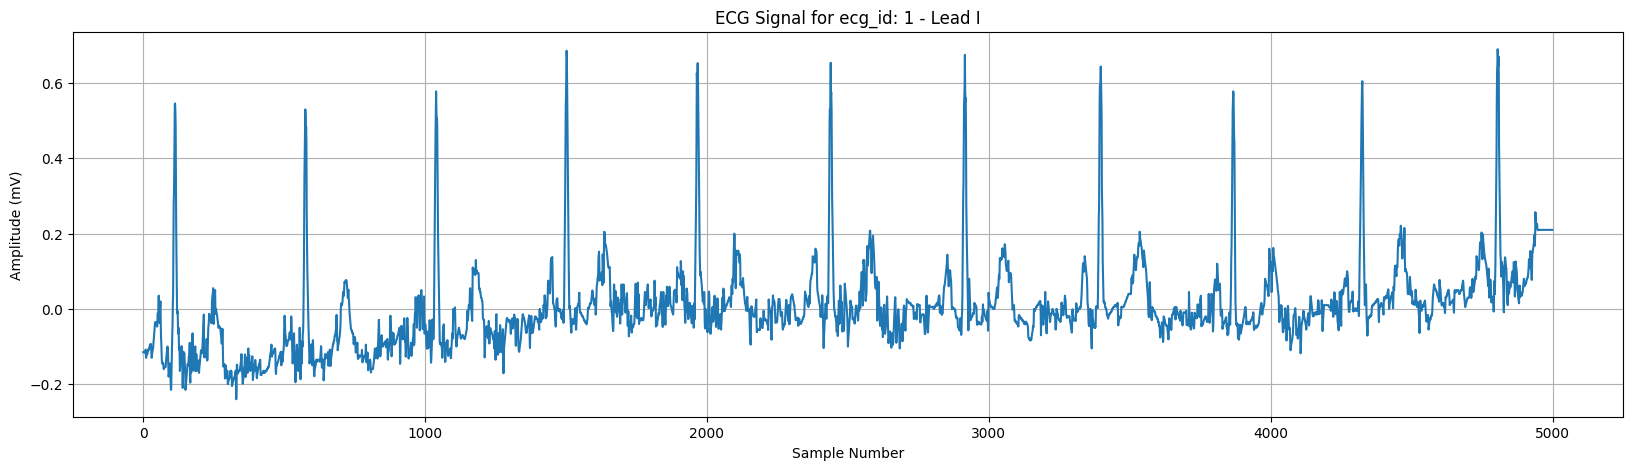


--- Signal Metadata ---
Sampling Frequency: 500 Hz
Signal Length: 5000 samples
Signal Leads: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


In [4]:
# --- Task C: Load and Visualize a Single ECG Signal ---
# Let's load the data for the very first ECG in our metadata table
sample_ecg_id = df_meta.index[0]

# Construct the full path to the high-resolution signal file
# Note: The filenames in the metadata don't have the .dat extension, so we add it
filename = os.path.join(DATA_PATH, df_meta.loc[sample_ecg_id, 'filename_hr'])

# Use the wfdb library to read the signal data
signal_data, signal_metadata = wfdb.rdsamp(filename)

# --- Plot the first lead of the ECG ---
plt.figure(figsize=(20, 5))
plt.plot(signal_data[:, 0]) # The signal_data is a NumPy array, we plot the first column (lead I)
plt.title(f'ECG Signal for ecg_id: {sample_ecg_id} - Lead I')
plt.xlabel('Sample Number')
plt.ylabel('Amplitude (mV)')
plt.grid(True)
plt.show()

# Print some metadata about the signal
print("\n--- Signal Metadata ---")
print(f"Sampling Frequency: {signal_metadata['fs']} Hz")
print(f"Signal Length: {signal_metadata['sig_len']} samples")
print(f"Signal Leads: {signal_metadata['sig_name']}")